# Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_0 = "data/data_part_0.parquet"
file_1 = "data_part_1.parquet"

df_0 = pd.read_parquet(file_0)
df_1 = pd.read_parquet(file_1)

df = pd.concat([df_0, df_1], ignore_index=True)
print(df.shape)

(1150000, 16)


In [2]:
df.head()

,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr
0,0,1,SMB,Energy,Monthly,0.054167,stable,4,0.017574,0.002766,0.102689,0,0.0,0,112.703497,50.000000
1,0,2,SMB,Energy,Monthly,0.054167,stable,11,0.027244,0.000000,0.102174,2,0.0,1,50.000000,51.903945
2,0,3,SMB,Energy,Monthly,0.054167,decline,12,0.004655,0.082195,0.195298,2,0.0,0,51.903945,50.000000
3,0,4,SMB,Energy,Monthly,0.054167,decline,17,-0.024496,0.062898,0.104958,3,0.5,1,50.000000,55.680067
4,0,5,SMB,Energy,Monthly,0.054167,decline,20,-0.073376,0.120356,0.076803,0,-1.0,0,55.680067,50.000000


In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "unique_values": df.nunique(),
    "missing_values": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

print(overview)

                         dtype  unique_values  missing_values  missing_pct
account_id               Int64          50000               0          0.0
month                    int64             23               0          0.0
company_size               str              3               0          0.0
industry                   str             10               0          0.0
contract_type              str              2               0          0.0
discount_pct           float64          50001               0          0.0
regime_state               str              3               0          0.0
active_users             int64            785               0          0.0
usage_growth           float64        1150000               0          0.0
feature_adoption_rate  float64        1023028               0          0.0
error_rate             float64        1133822               0          0.0
tickets_count            int64             42               0          0.0
ticket_growth          fl

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['account_id', 'month', 'discount_pct', 'active_users', 'usage_growth', 'feature_adoption_rate', 'error_rate', 'tickets_count', 'ticket_growth', 'payment_delay_flag', 'current_mrr', 'next_month_mrr']

Categorical columns:
['company_size', 'industry', 'contract_type', 'regime_state']


# Univariate Analysis

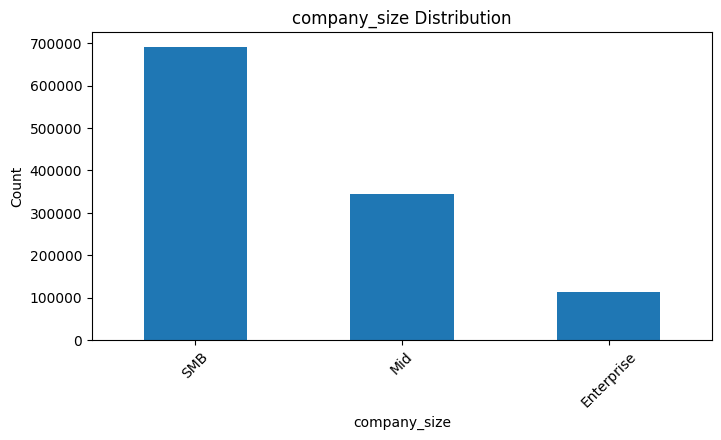

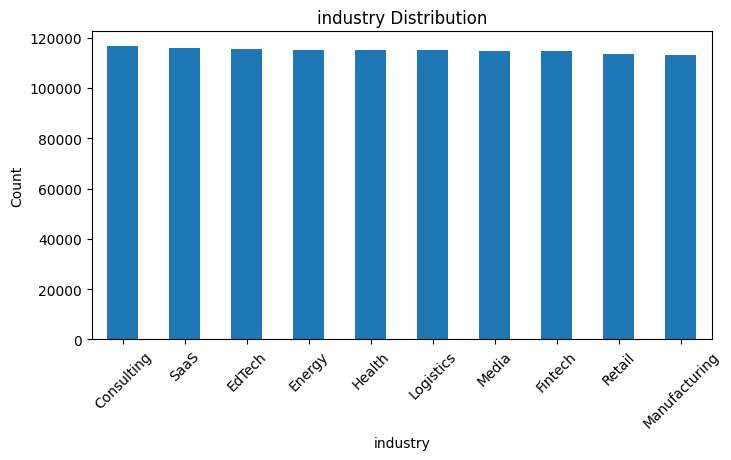

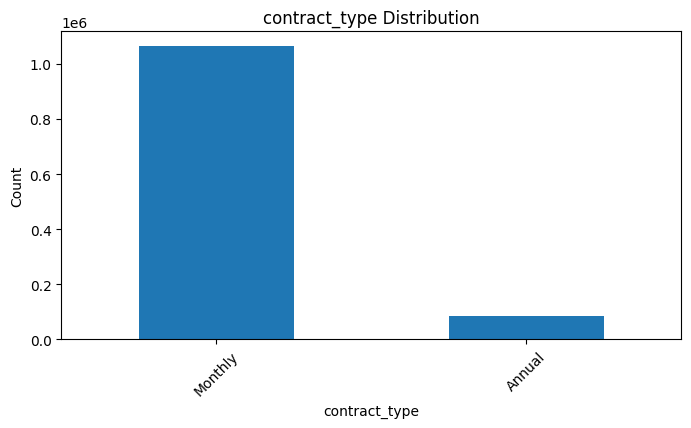

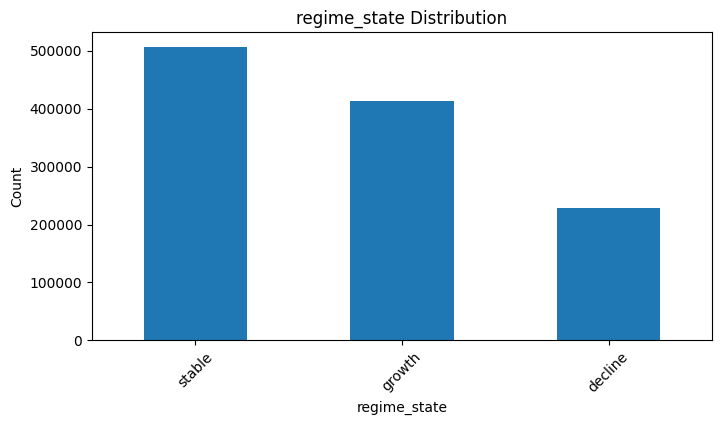

In [6]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    df[col].value_counts().plot(kind="bar")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

# Bivariate Analysis

In [7]:
df.groupby("company_size")[
    ["current_mrr", "next_month_mrr"]
].mean().sort_values(
    "current_mrr",
    ascending=False
)

,current_mrr,next_month_mrr
company_size,,
Enterprise,1826.409055,1627.708303
Mid,245.805549,213.609476
SMB,110.467945,106.010158


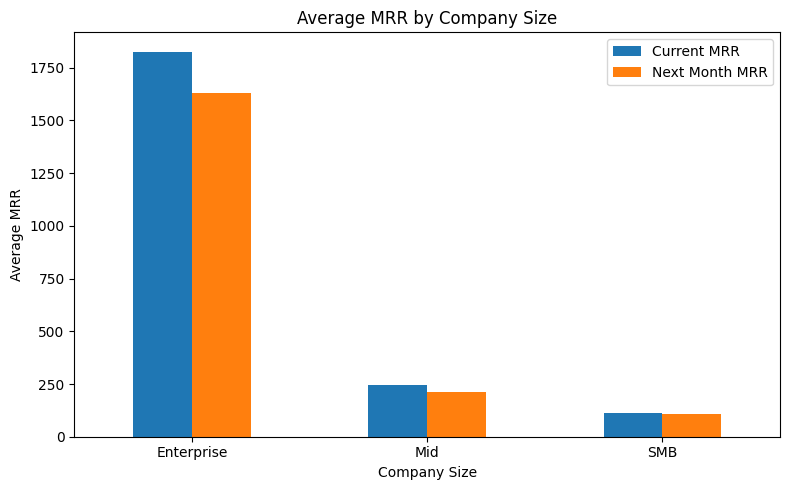

In [19]:
company_size_mrr = (
    df.groupby("company_size")[["current_mrr", "next_month_mrr"]]
    .mean()
    .sort_values("current_mrr", ascending=False)
)

company_size_mrr.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average MRR by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average MRR")
plt.xticks(rotation=0)
plt.legend(["Current MRR", "Next Month MRR"])
plt.tight_layout()
plt.show()

In [8]:
df.groupby("contract_type")[
    ["current_mrr", "next_month_mrr"]
].mean().sort_values(
    "current_mrr",
    ascending=False
)

,current_mrr,next_month_mrr
contract_type,,
Annual,1851.555421,1658.925137
Monthly,199.341535,180.092781


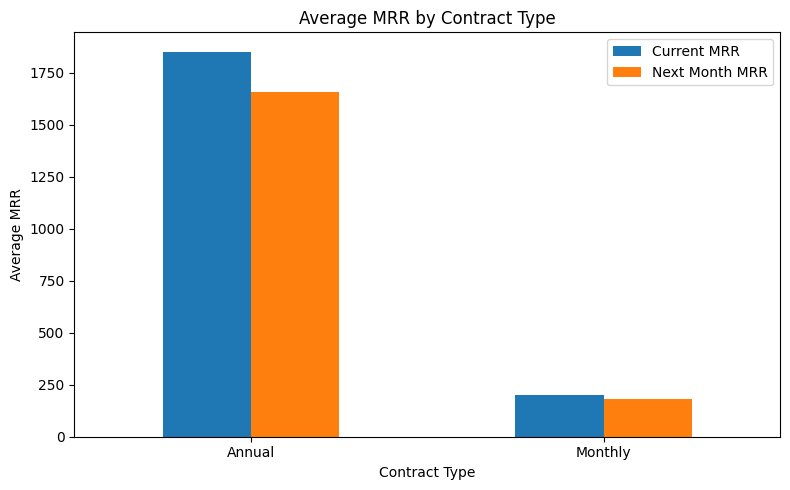

In [20]:
contract_mrr = (
    df.groupby("contract_type")[["current_mrr", "next_month_mrr"]]
    .mean()
    .sort_values("current_mrr", ascending=False)
)

contract_mrr.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average MRR by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Average MRR")
plt.xticks(rotation=0)
plt.legend(["Current MRR", "Next Month MRR"])
plt.tight_layout()
plt.show()

In [9]:
df.groupby("industry")[
    ["current_mrr", "next_month_mrr"]
].mean().sort_values(
    "current_mrr",
    ascending=False
)

,current_mrr,next_month_mrr
industry,,
EdTech,348.771720,319.436652
Energy,345.487450,315.015234
SaaS,323.550953,291.211469
Consulting,323.469952,291.943088
Logistics,318.342876,285.443936
Media,317.309829,287.029335
Retail,316.764796,282.272669
Fintech,312.944751,280.029512
Health,306.189049,273.876748


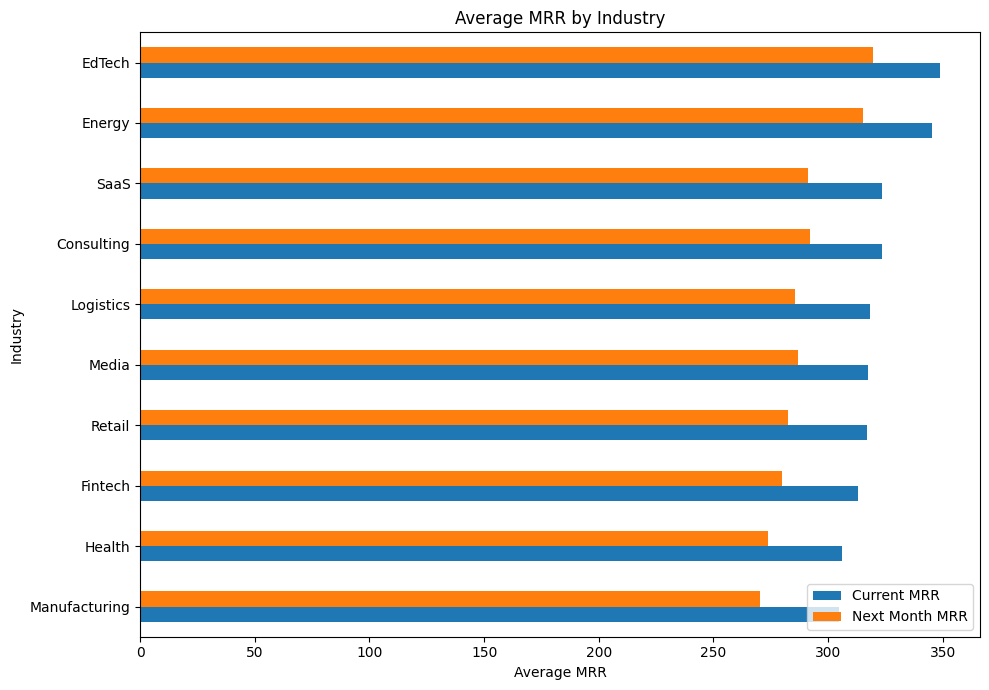

In [21]:
industry_mrr = (
    df.groupby("industry")[["current_mrr", "next_month_mrr"]]
    .mean()
    .sort_values("current_mrr", ascending=True)
)

industry_mrr.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Average MRR by Industry")
plt.xlabel("Average MRR")
plt.ylabel("Industry")
plt.legend(["Current MRR", "Next Month MRR"])
plt.tight_layout()
plt.show()

In [10]:
df.groupby("payment_delay_flag")[
    ["current_mrr", "next_month_mrr"]
].mean()

,current_mrr,next_month_mrr
payment_delay_flag,,
0,377.711765,332.967856
1,172.060638,173.826536


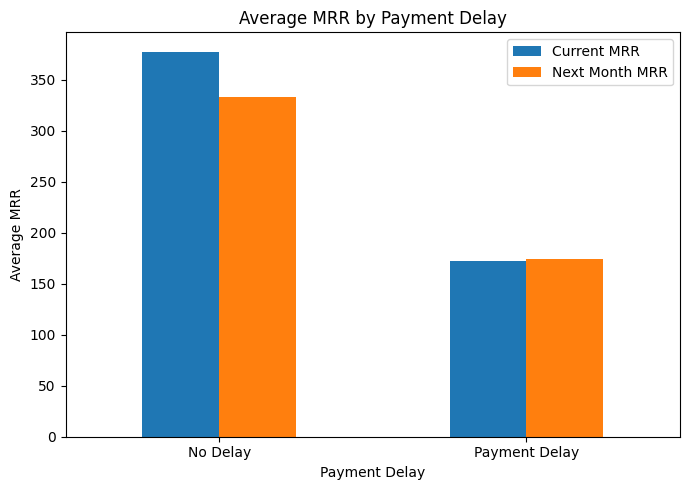

In [22]:
payment_delay_mrr = (
    df.groupby("payment_delay_flag")[["current_mrr", "next_month_mrr"]]
    .mean()
)

payment_delay_mrr.index = ["No Delay", "Payment Delay"]

payment_delay_mrr.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average MRR by Payment Delay")
plt.xlabel("Payment Delay")
plt.ylabel("Average MRR")
plt.xticks(rotation=0)
plt.legend(["Current MRR", "Next Month MRR"])
plt.tight_layout()
plt.show()

# Multivriate Analysis

In [12]:
pd.pivot_table(
    df,
    values="current_mrr",
    index="company_size",
    columns="contract_type",
    aggfunc="mean"
)

contract_type,Annual,Monthly
company_size,,
Enterprise,1851.555421,1753.086918
Mid,NaN,245.805549
SMB,NaN,110.467945


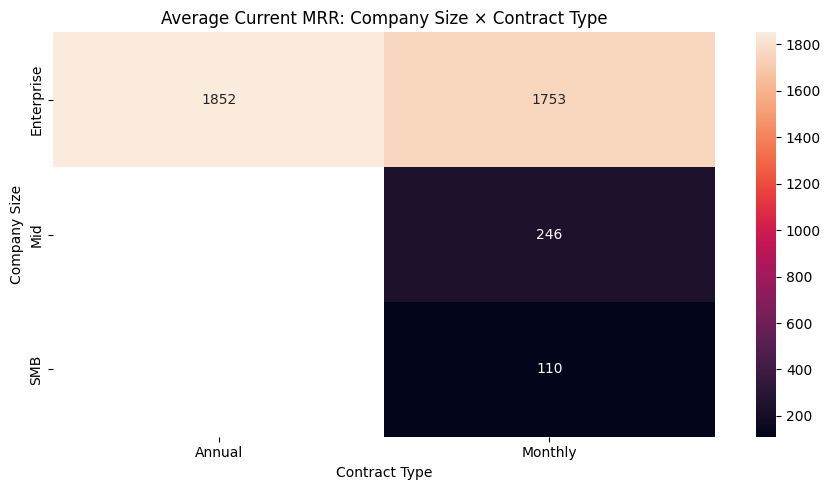

In [23]:
size_contract = pd.pivot_table(
    df,
    values="current_mrr",
    index="company_size",
    columns="contract_type",
    aggfunc="mean"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    size_contract,
    annot=True,
    fmt=".0f"
)

plt.title("Average Current MRR: Company Size × Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Company Size")
plt.tight_layout()
plt.show()

In [13]:
pd.pivot_table(
    df,
    values="current_mrr",
    index="company_size",
    columns="payment_delay_flag",
    aggfunc="mean"
)

payment_delay_flag,0,1
company_size,,
Enterprise,2039.305102,1102.989462
Mid,285.076622,132.480682
SMB,127.761240,67.391281


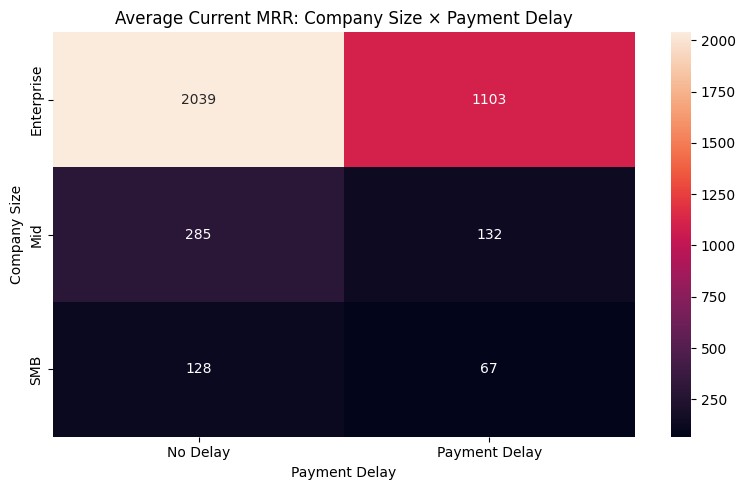

In [24]:
size_payment = pd.pivot_table(
    df,
    values="current_mrr",
    index="company_size",
    columns="payment_delay_flag",
    aggfunc="mean"
)

size_payment.columns = ["No Delay", "Payment Delay"]

plt.figure(figsize=(8, 5))

sns.heatmap(
    size_payment,
    annot=True,
    fmt=".0f"
)

plt.title("Average Current MRR: Company Size × Payment Delay")
plt.xlabel("Payment Delay")
plt.ylabel("Company Size")
plt.tight_layout()
plt.show()

In [14]:
pd.pivot_table(
    df,
    values="current_mrr",
    index="industry",
    columns="company_size",
    aggfunc="mean"
)

company_size,Enterprise,Mid,SMB
industry,,,
Consulting,1921.164911,234.470434,109.742564
EdTech,2052.166832,248.744715,112.485399
Energy,2085.854980,237.140763,110.853918
Fintech,1719.221968,251.349492,109.702295
Health,1696.828329,261.843446,110.405411
Logistics,1713.498056,253.491676,109.383206
Manufacturing,1692.843281,244.758789,111.373257
Media,1822.957533,245.734067,110.109151
Retail,1702.271109,241.138381,110.392170


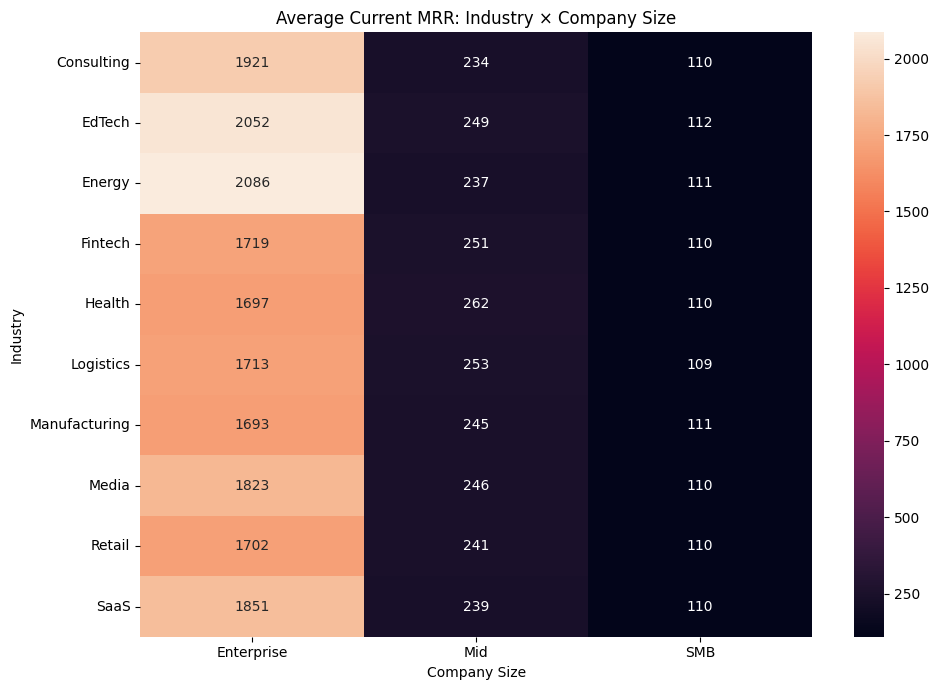

In [26]:
industry_size = pd.pivot_table(
    df,
    values="current_mrr",
    index="industry",
    columns="company_size",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    industry_size,
    annot=True,
    fmt=".0f"
)

plt.title("Average Current MRR: Industry × Company Size")
plt.xlabel("Company Size")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

# Time Analysis

In [15]:
print(df["month"].min())
print(df["month"].max())
print(df["month"].nunique())

1
23
23


In [16]:
monthly_revenue = df.groupby("month").agg(
    current_mrr=("current_mrr", "sum"),
    next_month_mrr=("next_month_mrr", "sum"),
    active_users=("active_users", "sum"),
    accounts=("account_id", "nunique")
).reset_index()

monthly_revenue

,month,current_mrr,next_month_mrr,active_users,accounts
0,1,6.013696e+07,4.165627e+07,350655,50000
1,2,4.201456e+07,2.561842e+07,722922,50000
2,3,2.583895e+07,1.658616e+07,1097228,50000
3,4,1.670316e+07,1.224213e+07,1470268,50000
4,5,1.234433e+07,9.881106e+06,1843959,50000
5,6,9.947318e+06,8.527880e+06,2218576,50000
6,7,8.565133e+06,7.795234e+06,2589720,50000
7,8,7.905504e+06,7.444975e+06,2966363,50000
8,9,7.489138e+06,7.216828e+06,3338698,50000
9,10,7.264619e+06,7.424178e+06,3712973,50000


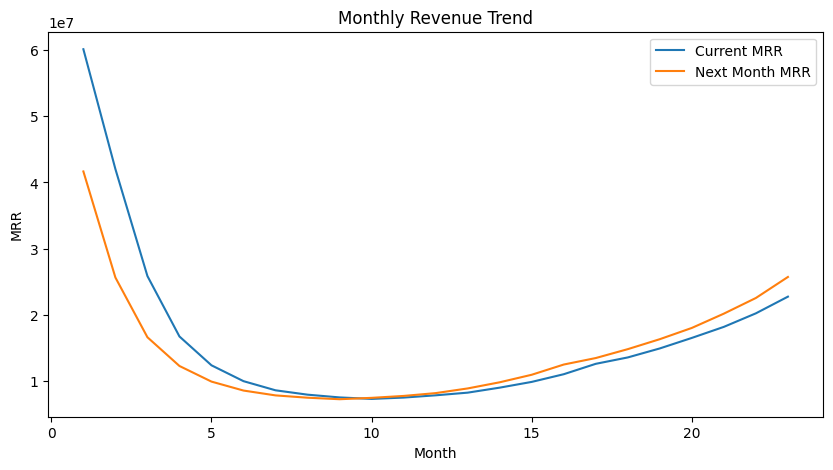

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["current_mrr"],
    label="Current MRR"
)

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["next_month_mrr"],
    label="Next Month MRR"
)

plt.xlabel("Month")
plt.ylabel("MRR")
plt.title("Monthly Revenue Trend")
plt.legend()

plt.show()

In [30]:
monthly_behavior = df.groupby("month").agg(
    usage_growth=("usage_growth", "mean"),
    feature_adoption=("feature_adoption_rate", "mean"),
    error_rate=("error_rate", "mean"),
    payment_delay=("payment_delay_flag", "mean"),
    ticket_growth=("ticket_growth", "mean")
)

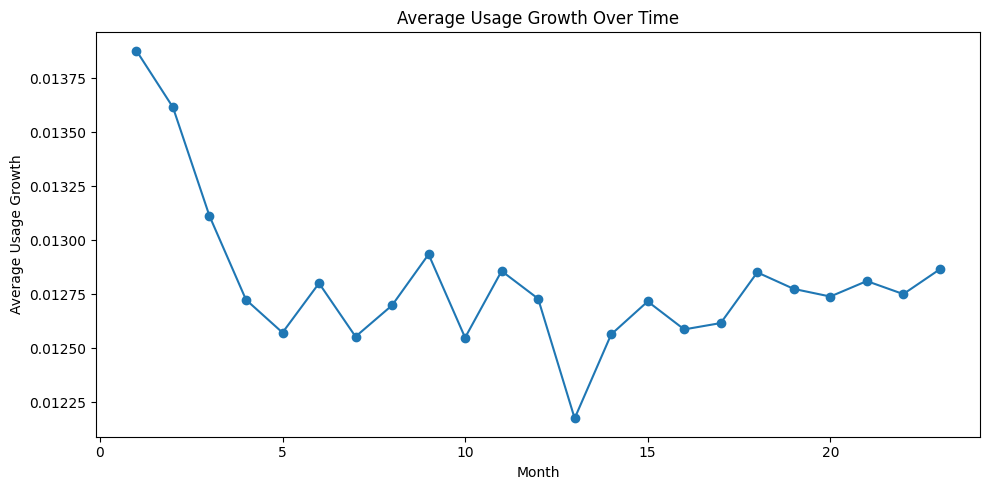

In [31]:
monthly_behavior["usage_growth"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Usage Growth Over Time")
plt.xlabel("Month")
plt.ylabel("Average Usage Growth")
plt.tight_layout()
plt.show()

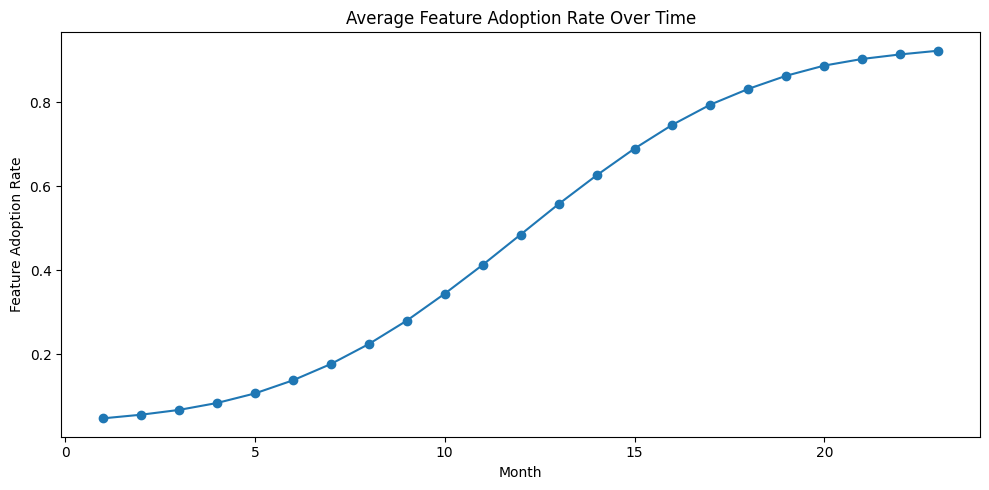

In [32]:
monthly_behavior["feature_adoption"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Feature Adoption Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Feature Adoption Rate")
plt.tight_layout()
plt.show()

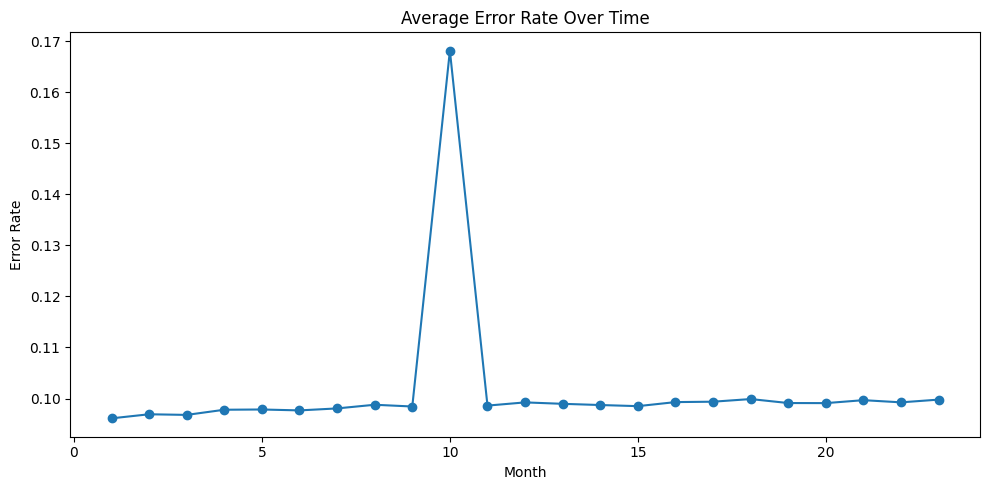

In [33]:
monthly_behavior["error_rate"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Error Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()

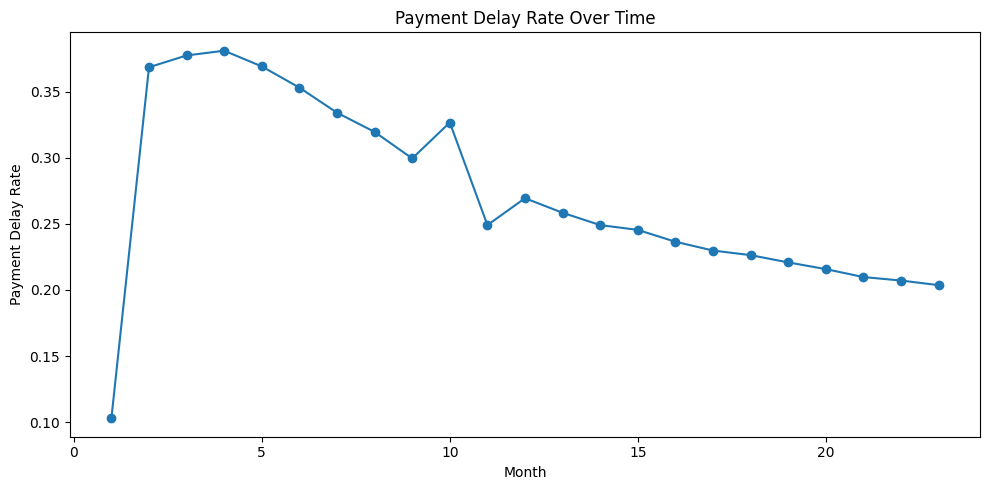

In [34]:
monthly_behavior["payment_delay"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Payment Delay Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Payment Delay Rate")
plt.tight_layout()
plt.show()

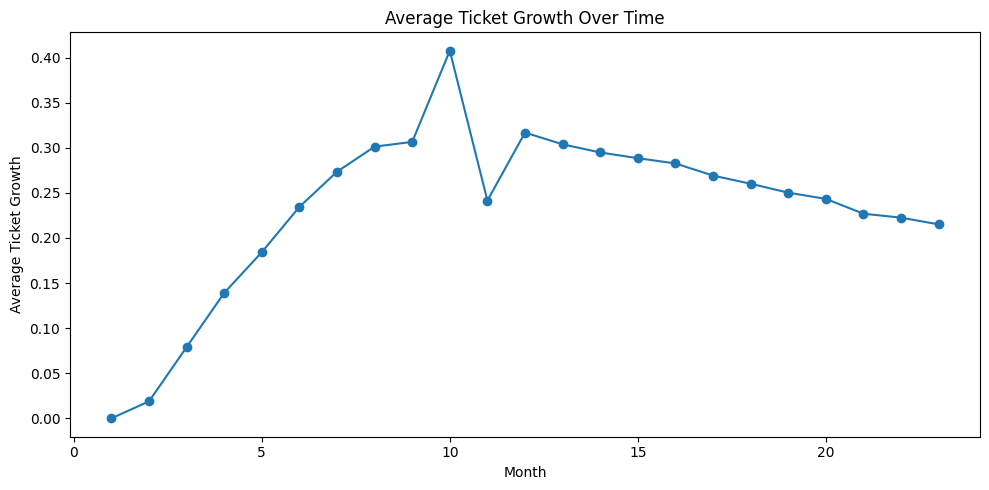

In [35]:
monthly_behavior["ticket_growth"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Ticket Growth Over Time")
plt.xlabel("Month")
plt.ylabel("Average Ticket Growth")
plt.tight_layout()
plt.show()

# Correlations

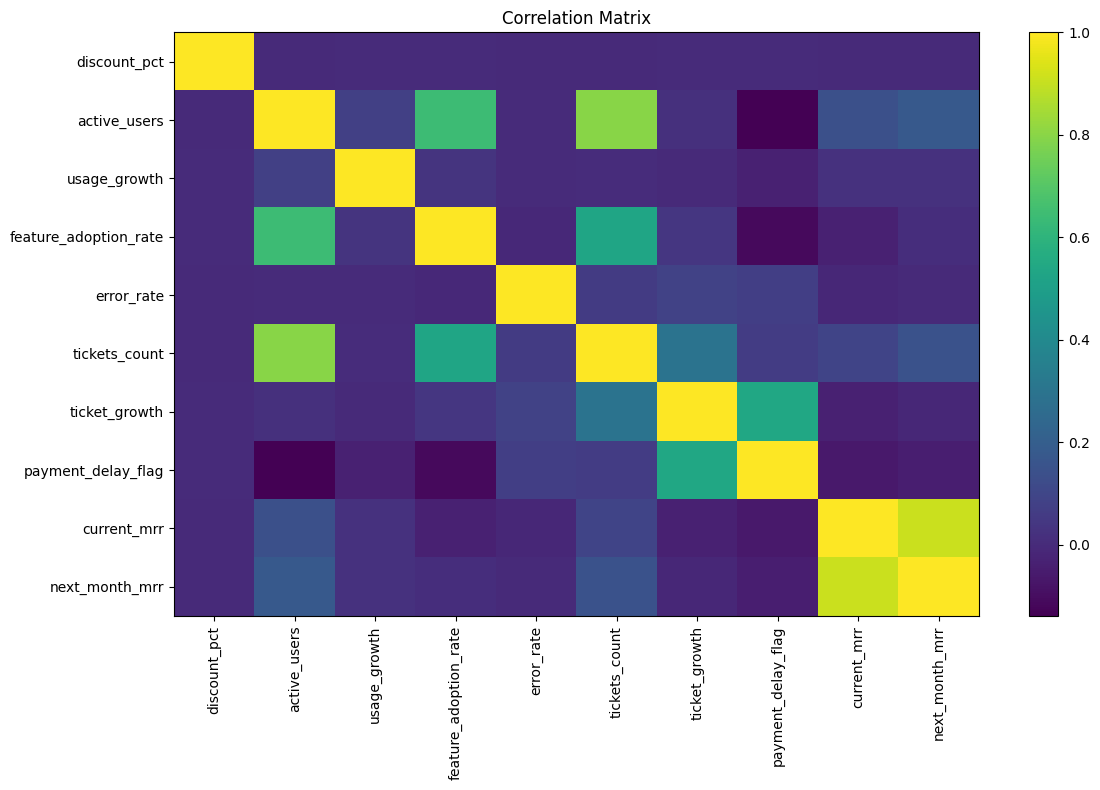

In [37]:
corr_cols = [
    "discount_pct",
    "active_users",
    "usage_growth",
    "feature_adoption_rate",
    "error_rate",
    "tickets_count",
    "ticket_growth",
    "payment_delay_flag",
    "current_mrr",
    "next_month_mrr"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()